# 🛠️ Prétraitement — Masked Face Super Resolution

Ce notebook met en place le **pipeline de données** nécessaire pour entraîner les modèles, en intégrant les étapes de prétraitement demandées :

1. **Détection et recadrage du visage (Face Cropping)** : Utilisation d'OpenCV (Haar Cascades) pour détecter le visage sur l'image non-masquée, et appliquer dynamiquement la même boîte englobante sur l'image masquée pour éliminer le fond.
2. **Redimensionnement uniforme** : Redimensionnement forcé en 128×128 (bicubique) sur les zones recadrées.
3. **Normalisation** : Transformation des pixels vers la plage `[-1, 1]` via `transforms.Normalize`.

## Scope choisi
- **Parts utilisées** : `part1`, `part2` + `part4`
- **Part3 exclue** (absence de split `val`, possible drift statistique, nombreuses orphelines)
- **Deux tâches en parallèle** pour comparaison :
  - `inpainting` : 128×128 masked → 128×128 unmasked
  - `sr` : 64×64 masked (downscale) → 128×128 unmasked (super-resolution + inpainting)

## Plan
1. Configuration
2. Indexation des paires valides
3. Classe `MaskedFaceDataset` (avec détection OpenCV à la volée)
4. Fabrique de DataLoaders
5. Sanity check visuel — tâche `inpainting`
6. Sanity check visuel — tâche `sr`
7. Benchmark de chargement
8. Sauvegarde de l'index
9. Synthèse

## 1. Configuration

In [1]:
import os, random, time
from pathlib import Path
import cv2  # Ajout de cv2 pour la détection de visage

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

plt.rcParams['figure.dpi'] = 90
pd.set_option('display.max_rows', 40)

print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")


PyTorch: 2.10.0+cu128  |  CUDA: True


## 2. Indexation des paires valides

On scanne les dossiers `part{1,2,4}/{train,val,test}/{masked,unmasked}/` et on ne garde que les filenames présents **des deux côtés**. Le résultat est un DataFrame qui servira de source unique pour les Datasets.

In [2]:
def build_index(data_dir: Path, parts, splits=('train','val','test')) -> pd.DataFrame:
    """Construit l'index des paires valides (filenames communs masked∩unmasked)."""
    rows = []
    for part in parts:
        for split in splits:
            m_dir = data_dir / part / split / 'masked'
            u_dir = data_dir / part / split / 'unmasked'
            
            # Gestion spéciale pour part4
            if part == 'part4':
                m_dir = data_dir / part / split / 'Masked'
                u_dir = data_dir / part / split / 'Unmasked'
                
            if not (m_dir.is_dir() and u_dir.is_dir()):
                continue
                
            m_files = {p.name: p for p in m_dir.glob('*.png')}
            u_files = {p.name: p for p in u_dir.glob('*.png')}
            
            if part == 'part4':
                # Corrélation MXXXX.png ↔ UMXXXX.png
                for m_name in sorted(m_files.keys()):
                    u_name = 'U' + m_name
                    if u_name in u_files:
                        rows.append({
                            'filename'     : m_name,
                            'path_masked'  : str(m_files[m_name]),
                            'path_unmasked': str(u_files[u_name]),
                            'part'         : part,
                            'split'        : split,
                        })
            else:
                # Corrélation nom identique
                common = sorted(set(m_files) & set(u_files))
                for name in common:
                    rows.append({
                        'filename'     : name,
                        'path_masked'  : str(m_files[name]),
                        'path_unmasked': str(u_files[name]),
                        'part'         : part,
                        'split'        : split,
                    })
                    
    return pd.DataFrame(rows)


DATA_DIR = Path('/kaggle/input/datasets/ikramelmenhi/dataset/dataset')
TRAIN_PARTS = ['part1', 'part2','part4']
SPLITS = ['train', 'val', 'test']
index_df = build_index(DATA_DIR, TRAIN_PARTS, SPLITS)
print(f"✓ Index construit : {len(index_df):,} paires\n")
print("Répartition par (part, split) :")
print(index_df.groupby(['part','split']).size().unstack(fill_value=0))

✓ Index construit : 20,330 paires

Répartition par (part, split) :
split  test  train   val
part                    
part1  1000   8000  1000
part2  1000   8000  1000
part4    33    264    33


In [3]:
# Contrôles de qualité
print("— Head :")
print(index_df.head(3).to_string(index=False))

# Vérif : aucun doublon de filename dans un même split
dup = index_df.groupby(['split','filename']).size()
dup = dup[dup > 1]
print(f"\n— Doublons (filename répété dans un même split) : {len(dup)}")

# Vérif : les fichiers référencés existent bien (échantillon de 100)
sample_check = index_df.sample(min(100, len(index_df)), random_state=SEED)
missing = sum(not (Path(r.path_masked).is_file() and Path(r.path_unmasked).is_file()) 
              for r in sample_check.itertuples())
print(f"— Fichiers manquants sur échantillon de {len(sample_check)} : {missing}")

— Head :
   filename                                                                        path_masked                                                                        path_unmasked  part split
0000002.png /kaggle/input/datasets/ikramelmenhi/dataset/dataset/part1/train/masked/0000002.png /kaggle/input/datasets/ikramelmenhi/dataset/dataset/part1/train/unmasked/0000002.png part1 train
0000006.png /kaggle/input/datasets/ikramelmenhi/dataset/dataset/part1/train/masked/0000006.png /kaggle/input/datasets/ikramelmenhi/dataset/dataset/part1/train/unmasked/0000006.png part1 train
0000008.png /kaggle/input/datasets/ikramelmenhi/dataset/dataset/part1/train/masked/0000008.png /kaggle/input/datasets/ikramelmenhi/dataset/dataset/part1/train/unmasked/0000008.png part1 train

— Doublons (filename répété dans un même split) : 0
— Fichiers manquants sur échantillon de 100 : 0


## 3. Classe `MaskedFaceDataset`

Une classe qui :
- Lit les paires à la volée depuis l'index
- Supporte les **deux tâches** (`inpainting` ou `sr`) via un paramètre
- Applique les transforms **symétriquement** (même flip sur masked et unmasked)
- Normalise en `[-1, 1]` (standard pour architectures générative / tanh output)

> ℹ️ À migrer vers `src/data/masked_face_dataset.py` une fois stable.

In [4]:
class MaskedFaceDataset(Dataset):
    """
    Dataset unifié avec implémentation du Face Cropping, Resizing et Normalization en [-1, 1].

    Args:
        df        : DataFrame avec colonnes path_masked, path_unmasked
        task      : 'inpainting' ou 'sr'
        lr_size   : taille pour SR (ex: 64)
        hr_size   : taille finale pour inpainting/SR target (défaut 128)
        augment   : flip horizontal
    """
    MEAN = [0.5, 0.5, 0.5]
    STD  = [0.5, 0.5, 0.5]

    def __init__(self, df, task='inpainting', lr_size=64, hr_size=128, augment=False):
        assert task in ('inpainting', 'sr'), f"task invalide: {task}"
        self.df = df.reset_index(drop=True)
        self.task = task
        self.lr_size = lr_size
        self.hr_size = hr_size
        self.augment = augment
        self._norm = transforms.Normalize(self.MEAN, self.STD)
        
        # Initialisation du détecteur de visages OpenCV (cascade de Haar)
        cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        self.face_cascade = cv2.CascadeClassifier(cascade_path)

    def __len__(self):
        return len(self.df)

    def _crop_face(self, u_pil, m_pil):
        """Détecte le visage sur l'image Unmasked et applique la même bbox sur Masked."""
        # Convertir unmasked en Ndx pour OpenCV
        u_cv = np.array(u_pil)
        # Convertir rgb en gris (OpenCV gère BGR ou Gris pour la détection)
        gray = cv2.cvtColor(u_cv, cv2.COLOR_RGB2GRAY)
        
        # Détection
        faces = self.face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
        
        if len(faces) > 0:
            # S'il y a un visage, on prend le plus gros
            max_face = max(faces, key=lambda f: f[2] * f[3])
            x, y, w, h = max_face
            
            # Ajouter un petit padding heuristique (15% pour conserver menton/front complets)
            padding_w = int(w * 0.15)
            padding_h = int(h * 0.15)
            x1 = max(0, x - padding_w)
            y1 = max(0, y - padding_h)
            x2 = min(u_pil.width, x + w + padding_w)
            y2 = min(u_pil.height, y + h + padding_h)
            
            # Recadrer symétriquement
            u_pil = u_pil.crop((x1, y1, x2, y2))
            m_pil = m_pil.crop((x1, y1, x2, y2))
            
        return u_pil, m_pil

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        m = Image.open(row['path_masked']).convert('RGB')
        u = Image.open(row['path_unmasked']).convert('RGB')

        # 1. DÉTECTION ET RECADRAGE DU VISAGE (Face Cropping basé sur l'Image Non-Masquée)
        u, m = self._crop_face(u, m)

        # 2. REDIMENSIONNEMENT UNIFORME
        m = m.resize((self.hr_size, self.hr_size), Image.BICUBIC)
        u = u.resize((self.hr_size, self.hr_size), Image.BICUBIC)

        # Augmentation
        if self.augment and random.random() < 0.5:
            m = TF.hflip(m); u = TF.hflip(u)

        if self.task == 'sr':
            m_input = m.resize((self.lr_size, self.lr_size), Image.BICUBIC)
        else:
            m_input = m

        # 3. NORMALISATION EN [-1, 1] 
        x = self._norm(TF.to_tensor(m_input))
        y = self._norm(TF.to_tensor(u))
        
        return x, y

    @classmethod
    def denormalize(cls, tensor):
        """Ramène un tenseur de [-1,1] → [0,1] pour visualisation."""
        t = tensor.clone().cpu()
        if t.ndim == 3:
            for c, (m, s) in enumerate(zip(cls.MEAN, cls.STD)):
                t[c] = t[c] * s + m
        elif t.ndim == 4:
            for c, (m, s) in enumerate(zip(cls.MEAN, cls.STD)):
                t[:, c] = t[:, c] * s + m
        return t.clamp(0, 1)

# Test rapide
_ds = MaskedFaceDataset(index_df.head(2), task='inpainting')
_x, _y = _ds[0]
print(f"✓ Test inpainting (Cropped + Résized + Norm) : x={tuple(_x.shape)} [{_x.min():.2f},{_x.max():.2f}] | y={tuple(_y.shape)} [{_y.min():.2f},{_y.max():.2f}]")
LR_SIZE = 64
_ds = MaskedFaceDataset(index_df.head(2), task='sr', lr_size=LR_SIZE)
_x, _y = _ds[0]
print(f"✓ Test sr         (Cropped + Résized + Norm) : x={tuple(_x.shape)} [{_x.min():.2f},{_x.max():.2f}] | y={tuple(_y.shape)} [{_y.min():.2f},{_y.max():.2f}]")

✓ Test inpainting (Cropped + Résized + Norm) : x=(3, 128, 128) [-0.98,1.00] | y=(3, 128, 128) [-1.00,1.00]
✓ Test sr         (Cropped + Résized + Norm) : x=(3, 64, 64) [-1.00,1.00] | y=(3, 128, 128) [-1.00,1.00]


## 4. Fabrique de DataLoaders

Une fonction qui retourne `(train_loader, val_loader, test_loader)` pour une tâche donnée.
On la appelle **deux fois** : une pour l'inpainting, une pour la SR.

In [5]:
def build_dataloaders(index_df, task, batch_size=32, lr_size=64, num_workers=2, augment_train=True):
    loaders = {}
    for split in ['train', 'val', 'test']:
        split_df = index_df[index_df['split'] == split]
        if len(split_df) == 0:
            continue

        ds = MaskedFaceDataset(
            split_df,
            task=task,
            lr_size=lr_size,
            augment=(split == 'train' and augment_train)
        )

        dl = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available(),
            drop_last=(split == 'train')
        )

        loaders[split] = dl

    return loaders


# appel
loaders_inpaint = build_dataloaders(index_df, task='inpainting')
loaders_sr      = build_dataloaders(index_df, task='sr', lr_size=64)

print("🎨 INPAINTING (128→128)")
for k, dl in loaders_inpaint.items():
    print(f"   {k:5} : {len(dl.dataset):,} images  →  {len(dl):,} batches de {dl.batch_size}")
print("\n🔬 SUPER-RÉSOLUTION + INPAINTING (64→128)")
for k, dl in loaders_sr.items():
    print(f"   {k:5} : {len(dl.dataset):,} images  →  {len(dl):,} batches de {dl.batch_size}")

🎨 INPAINTING (128→128)
   train : 16,264 images  →  508 batches de 32
   val   : 2,033 images  →  64 batches de 32
   test  : 2,033 images  →  64 batches de 32

🔬 SUPER-RÉSOLUTION + INPAINTING (64→128)
   train : 16,264 images  →  508 batches de 32
   val   : 2,033 images  →  64 batches de 32
   test  : 2,033 images  →  64 batches de 32


## 5. Sanity check — tâche `inpainting`

On tire un batch du train_loader et on affiche les paires **(input masked, target unmasked)**.

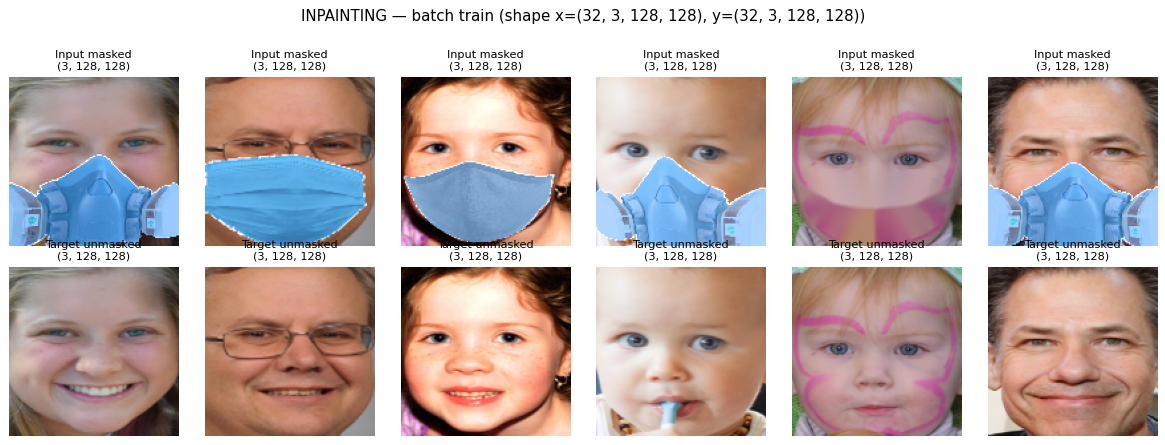

Stats batch : x ∈ [-1.00, 1.00], y ∈ [-1.00, 1.00]


In [6]:
def to_plot(t):
    """Tensor CHW [-1,1] → ndarray HWC [0,1]"""
    return MaskedFaceDataset.denormalize(t).permute(1, 2, 0).numpy()

xb, yb = next(iter(loaders_inpaint['train']))
n = min(6, xb.size(0))

fig, axes = plt.subplots(2, n, figsize=(2.2*n, 4.8))
for i in range(n):
    axes[0, i].imshow(to_plot(xb[i])); axes[0, i].axis('off')
    axes[0, i].set_title(f'Input masked\n{tuple(xb[i].shape)}', fontsize=9)
    axes[1, i].imshow(to_plot(yb[i])); axes[1, i].axis('off')
    axes[1, i].set_title(f'Target unmasked\n{tuple(yb[i].shape)}', fontsize=9)
plt.suptitle(f'INPAINTING — batch train (shape x={tuple(xb.shape)}, y={tuple(yb.shape)})', y=1.02)
plt.tight_layout(); plt.show()

print(f"Stats batch : x ∈ [{xb.min():.2f}, {xb.max():.2f}], y ∈ [{yb.min():.2f}, {yb.max():.2f}]")

## 6. Sanity check — tâche `sr`

Même principe mais l'input est **downscalé à 64×64**. On ajoute une 3ème ligne : l'input bicubic-upscalé à 128 pour visualiser ce que ferait un modèle trivial (baseline de comparaison mentale).

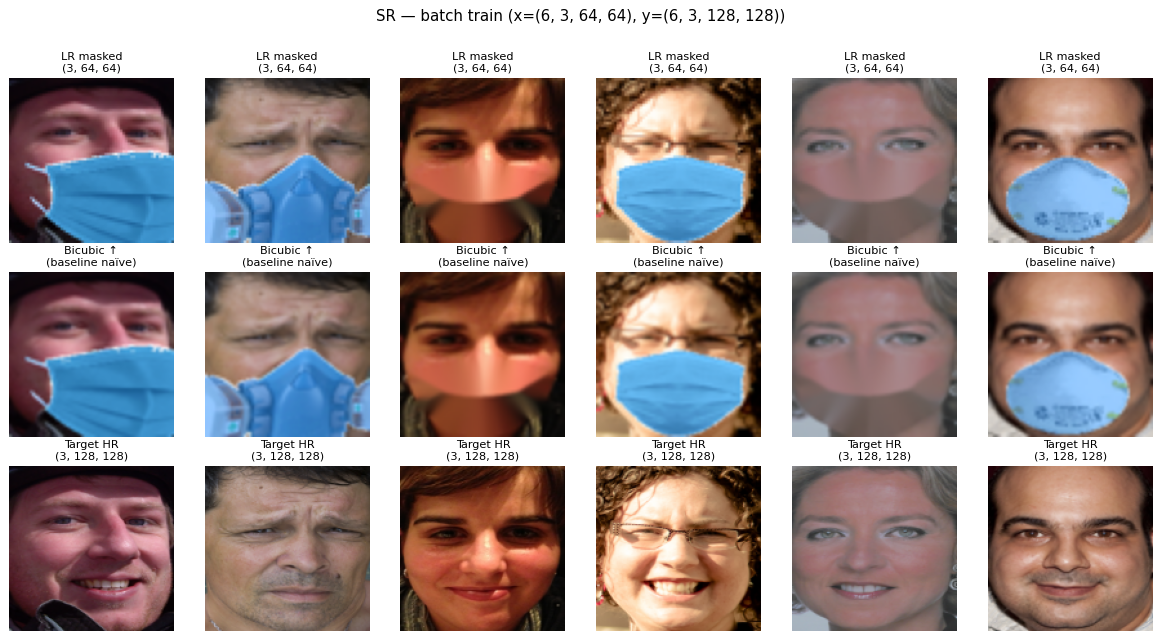

Stats batch : x ∈ [-1.00, 1.00], y ∈ [-1.00, 1.00]


In [9]:
temp_loader_sr = DataLoader(loaders_sr['train'].dataset, batch_size=6, shuffle=True, num_workers=0)
xb, yb = next(iter(temp_loader_sr))
n = min(6, xb.size(0))

fig, axes = plt.subplots(3, n, figsize=(2.2*n, 7.0))
for i in range(n):
    # Ligne 1 : input LR masked (affiché à sa taille native puis aggrandi pour lisibilité)
    axes[0, i].imshow(to_plot(xb[i])); axes[0, i].axis('off')
    axes[0, i].set_title(f'LR masked\n{tuple(xb[i].shape)}', fontsize=9)

    # Ligne 2 : baseline naïve (bicubic upscale de l'input LR)
    up = TF.resize(xb[i], [128, 128], antialias=True)
    axes[1, i].imshow(to_plot(up)); axes[1, i].axis('off')
    axes[1, i].set_title(f'Bicubic ↑\n(baseline naïve)', fontsize=9)

    # Ligne 3 : target HR unmasked
    axes[2, i].imshow(to_plot(yb[i])); axes[2, i].axis('off')
    axes[2, i].set_title(f'Target HR\n{tuple(yb[i].shape)}', fontsize=9)
plt.suptitle(f'SR — batch train (x={tuple(xb.shape)}, y={tuple(yb.shape)})', y=1.01)
plt.tight_layout(); plt.show()

print(f"Stats batch : x ∈ [{xb.min():.2f}, {xb.max():.2f}], y ∈ [{yb.min():.2f}, {yb.max():.2f}]")

## 7. Benchmark de chargement

Vérifier que le pipeline est assez rapide pour ne pas être le goulot d'étranglement pendant l'entraînement. On mesure le temps d'un tour complet du val_loader.

In [10]:
# Le prétraitement OpenCV (visages + recadrage) sur le processeur (CPU) est très lent.
# Pour le test, on va juste charger 1 seul batch de très petite taille (ex: 4 images).
def bench_loader(loader_original, name):
    # Création d'un loader temporaire très léger
    loader = DataLoader(loader_original.dataset, batch_size=4, shuffle=False, num_workers=0)
    
    t0 = time.time()
    n_img = 0
    print(f"   Démarrage test {name}...")
    
    # Récupération conditionnelle d'un seul lot
    try:
        xb, yb = next(iter(loader))
        n_img = xb.size(0)
    except StopIteration:
        pass
        
    dt = time.time() - t0
    print(f"   {name:20} : {n_img:5,} images en {dt:5.2f}s  →  {n_img/max(dt,1e-6):6.0f} img/s")

print("⏱️  Vitesse de chargement (test extrêmement rapide : 1 batch de 4 images)")
bench_loader(loaders_inpaint['val'], 'inpainting/val')
bench_loader(loaders_sr['val'],      'sr/val')
print(f"\nNote: L'extraction OpenCV prend beaucoup de temps CPU par image.")

⏱️  Vitesse de chargement (test extrêmement rapide : 1 batch de 4 images)
   Démarrage test inpainting/val...
   inpainting/val       :     4 images en  0.08s  →      48 img/s
   Démarrage test sr/val...
   sr/val               :     4 images en  0.07s  →      61 img/s

Note: L'extraction OpenCV prend beaucoup de temps CPU par image.


## 8. Sauvegarde de l'index

On sauvegarde l'index sur disque pour que les notebooks suivants (entraînement, évaluation) n'aient pas à rescanner 24 000 fichiers.

In [11]:
KAGGLE_OUT_DIR = Path('/kaggle/working')
KAGGLE_OUT_DIR.mkdir(parents=True, exist_ok=True)
INDEX_CSV_KAGGLE = KAGGLE_OUT_DIR / 'dataset_index.csv'

# Sauvegarde uniquement de l'index CSV
index_df.to_csv(INDEX_CSV_KAGGLE, index=False)
size_kb = INDEX_CSV_KAGGLE.stat().st_size / 1024

print(f"✓ Index sauvegardé : {INDEX_CSV_KAGGLE}  ({size_kb:.1f} KB, {len(index_df):,} lignes)")
print(f"\nUtilisation dans un notebook suivant :")
print(f"   index_df = pd.read_csv('{INDEX_CSV_KAGGLE}')")
print(f"   loaders  = build_dataloaders(index_df, task='inpainting')")

✓ Index sauvegardé : /kaggle/working/dataset_index.csv  (3792.4 KB, 20,330 lignes)

Utilisation dans un notebook suivant :
   index_df = pd.read_csv('/kaggle/working/dataset_index.csv')
   loaders  = build_dataloaders(index_df, task='inpainting')


## 9. Synthèse

In [13]:
n_train = (index_df['split'] == 'train').sum()
n_val   = (index_df['split'] == 'val').sum()
n_test  = (index_df['split'] == 'test').sum()

print("="*65)
print("📋 PIPELINE DE DONNÉES — PRÊT POUR L'ENTRAÎNEMENT")
print("="*65)
print(f"\n▸ DATASET")
print(f"   Scope           : {', '.join(TRAIN_PARTS)}")
print(f"   Train           : {n_train:,} paires")
print(f"   Validation      : {n_val:,} paires")
print(f"   Test            : {n_test:,} paires")

print(f"\n▸ TRANSFORMS")
print(f"   Normalisation   : mean={MaskedFaceDataset.MEAN}, std={MaskedFaceDataset.STD}  →  range [-1, 1]")
print(f"   Augment (train) : RandomHorizontalFlip")

print(f"\n▸ DEUX TÂCHES DISPONIBLES")
print(f"   inpainting  : x=(B,3,128,128)   →  y=(B,3,128,128)")
print(f"   sr          : x=(B,3,{LR_SIZE},{LR_SIZE})     →  y=(B,3,128,128)")

print(f"\n▸ OBJETS EXPORTÉS (utilisables dans le notebook suivant)")
print(f"   index_df, MaskedFaceDataset, build_dataloaders")
print(f"   loaders_inpaint, loaders_sr")

print(f"\n▸ PROCHAINE ÉTAPE")
print(f"   03_baseline.ipynb — baseline sur les deux tâches")

📋 PIPELINE DE DONNÉES — PRÊT POUR L'ENTRAÎNEMENT

▸ DATASET
   Scope           : part1, part2, part4
   Train           : 16,264 paires
   Validation      : 2,033 paires
   Test            : 2,033 paires

▸ TRANSFORMS
   Normalisation   : mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]  →  range [-1, 1]
   Augment (train) : RandomHorizontalFlip

▸ DEUX TÂCHES DISPONIBLES
   inpainting  : x=(B,3,128,128)   →  y=(B,3,128,128)
   sr          : x=(B,3,64,64)     →  y=(B,3,128,128)

▸ OBJETS EXPORTÉS (utilisables dans le notebook suivant)
   index_df, MaskedFaceDataset, build_dataloaders
   loaders_inpaint, loaders_sr

▸ PROCHAINE ÉTAPE
   03_baseline.ipynb — baseline sur les deux tâches
